# TFT Test Set Evaluation — Zaragoza Solar Forecast

This notebook evaluates the trained TFT model on the held-out test set (2025-07-01 to 2025-12-31).
The test set is touched **exactly once** here. No model selection or hyperparameter decisions are
made in this notebook.

**MLVU evaluation principle:** the test set is a simulation of production deployment. Any information
available during evaluation that wouldn't exist in production constitutes leakage.

**Pipeline steps:**

| # | Step | Purpose |
|---|---|---|
| 0 | Imports & configuration | Libraries, load preprocessing and training params |
| 1 | Reconstruct dataset for test split | Continuous time_idx across all splits |
| 2 | Load model & generate predictions | Best checkpoint from training |
| 3 | Test metrics | RMSE, MAE, R², MASE on original MWh scale |
| 4 | Baseline comparisons | Persistence (24h), climatological (hourly mean) |
| 5 | Visualizations | Time series, scatter, residuals, TFT interpretability |
| 6 | Summary | Final results table |

## Step 0 — Imports & configuration

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

import functools

if not getattr(torch, '_orig_load', None):
    torch._orig_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return torch._orig_load(*args, **kwargs)
torch.load = _patched_torch_load

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Paths ──
DATA_DIR  = os.path.join(os.getcwd(), 'data')
MODEL_DIR = os.path.join(os.getcwd(), 'models', 'perfect_forecast')

# ── Sequence lengths ──
MAX_ENCODER_LENGTH    = 168
MAX_PREDICTION_LENGTH = 24

# ── Feature classification (must match training notebook!) ──
# Perfect-forecast experiment: all weather features are known-future
KNOWN_FUTURE = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi',
    # ERA5 weather — treated as known-future in the perfect-forecast experiment
    'dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa',
    'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'kt', 'dewpoint_depression_C',
]
OBSERVED = []  # all weather moved to known-future
TARGET = 'pv_generation_mwh'

# ── Load params ──
with open(os.path.join(DATA_DIR, 'preprocessing_params.json')) as f:
    pp = json.load(f)
TARGET_MEAN = pp['target_mean']
TARGET_STD  = pp['target_std']

with open(os.path.join(MODEL_DIR, 'hp_study_results_pf.json')) as f:
    hp_results = json.load(f)

print(f"Best HPs from training: {hp_results['best_params']}")
print(f"Val metrics: {hp_results['val_metrics_mwh']}")
print(f"Target denorm: z * {TARGET_STD:.4f} + {TARGET_MEAN:.4f}")

Best HPs from training: {'hidden_size': 16, 'lstm_layers': 1, 'attention_head_size': 4, 'dropout': 0.21388127302606708, 'hidden_continuous_size': 8, 'learning_rate': 0.000335154783106822}
Val metrics: {'MAE_MWh': 91.43463897705078, 'RMSE_MWh': 168.16070556640625, 'R2': 0.8663371205329895}
Target denorm: z * 443.4560 + 335.7786


c:\Users\nicol\Documents\ML-solar-forecast\.venv\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Step 1 — Reconstruct dataset for test split

In [2]:
# ── Load all three splits ──
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'val_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()

# ── Continuous time_idx across all three splits ──
train_df['time_idx'] = np.arange(len(train_df))
val_df['time_idx']   = np.arange(len(train_df), len(train_df) + len(val_df))
test_df['time_idx']  = np.arange(len(train_df) + len(val_df),
                                  len(train_df) + len(val_df) + len(test_df))

train_df['group_id'] = '0'
val_df['group_id']   = '0'
test_df['group_id']  = '0'

print(f"Train: {len(train_df):,} rows  time_idx [0, {train_df['time_idx'].max()}]")
print(f"Val:   {len(val_df):,} rows   time_idx [{val_df['time_idx'].min()}, {val_df['time_idx'].max()}]")
print(f"Test:  {len(test_df):,} rows  time_idx [{test_df['time_idx'].min()}, {test_df['time_idx'].max()}]")

Train: 17,544 rows  time_idx [0, 17543]
Val:   4,344 rows   time_idx [17544, 21887]
Test:  4,416 rows  time_idx [21888, 26303]


In [3]:
# ── Reconstruct training dataset (needed for from_dataset) ──
# Must match the feature classification used during training.
dataset_kwargs = dict(
    time_idx='time_idx',
    target=TARGET,
    group_ids=['group_id'],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,
    time_varying_known_reals=KNOWN_FUTURE,
    target_normalizer=None,
    scalers={col: None for col in KNOWN_FUTURE},
    add_relative_time_idx=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

# Only add time_varying_unknown_reals if OBSERVED is non-empty
if OBSERVED:
    dataset_kwargs['time_varying_unknown_reals'] = OBSERVED
    dataset_kwargs['scalers'].update({col: None for col in OBSERVED})

training_dataset = TimeSeriesDataSet(train_df, **dataset_kwargs)

# ── Test dataset with encoder context from val tail ──
# ignore_index=True: val_df.iloc[-168:] has index ~4176-4343 and test_df has
# index 0-4367, making the concat index non-monotonic without it.
# predict=True is intentionally omitted — we want full sliding-window evaluation
# (same as val_dataset in training), not just the final prediction window.
test_with_context = pd.concat([
    val_df.iloc[-MAX_ENCODER_LENGTH:],
    test_df
], ignore_index=True)

test_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    test_with_context,
    stop_randomization=True,
)

test_dataloader = test_dataset.to_dataloader(
    train=False, batch_size=64, num_workers=2
)

print(f"Test dataset: {len(test_dataset)} samples")
assert len(test_dataset) > 100, \
    f"Test dataset too small ({len(test_dataset)}): check concat/context construction"

Test dataset: 4393 samples


## Step 2 — Load model & generate predictions

In [4]:
def denormalize(z_values):
    """Convert z-score normalized values back to original MWh scale."""
    return z_values * TARGET_STD + TARGET_MEAN

def compute_metrics(actual_mwh, predicted_mwh):
    """Compute RMSE, MAE, R² on original MWh scale."""
    residuals = actual_mwh - predicted_mwh
    mae  = np.abs(residuals).mean()
    rmse = np.sqrt((residuals ** 2).mean())
    ss_res = (residuals ** 2).sum()
    ss_tot = ((actual_mwh - actual_mwh.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    nrmse = (rmse / TARGET_MEAN) * 100  # normalized by train-set mean
    return {'MAE_MWh': float(mae), 'RMSE_MWh': float(rmse), 'R2': float(r2), 'nRMSE_pct': float(nrmse)}

In [5]:
# Load best model checkpoint
ckpt_path = os.path.join(MODEL_DIR, 'tft_pf_best.ckpt')
best_model = TemporalFusionTransformer.load_from_checkpoint(ckpt_path)
best_model.eval()
print(f"Loaded model from {ckpt_path}")
print(f"Model parameters: {sum(p.numel() for p in best_model.parameters()):,}")

Loaded model from c:\Users\nicol\Documents\ML-solar-forecast\zaragoza\models\perfect_forecast\tft_pf_best.ckpt
Model parameters: 40,199


In [6]:
# Generate predictions
test_predictions = best_model.predict(
    test_dataloader, mode='prediction', return_x=True, return_y=True,
)
test_raw = best_model.predict(
    test_dataloader, mode='raw', return_x=True
)

# Extract prediction windows (n_windows, 24)
pred_z   = test_predictions.output.cpu().numpy()
actual_z = test_predictions.y[0].cpu().numpy()

# ── Per-timestep aggregation ──
# The TFT produces overlapping 24h windows: window i predicts hours [i, i+23].
# Each test hour gets predicted by up to 24 different windows at different horizons.
# We average all predictions for each timestep to get one prediction per hour,
# ensuring metrics are computed on the same basis as XGBoost (one pred per hour).
n_test = len(test_df)
agg_sum = np.zeros(n_test)
agg_count = np.zeros(n_test)
n_windows = pred_z.shape[0]
for i in range(n_windows):
    for h in range(MAX_PREDICTION_LENGTH):
        t = i + h
        if t < n_test:
            agg_sum[t] += pred_z[i, h]
            agg_count[t] += 1
mask = agg_count > 0
pred_z_agg = np.zeros(n_test)
pred_z_agg[mask] = agg_sum[mask] / agg_count[mask]

pred_mwh   = np.clip(denormalize(pred_z_agg), 0, None)
actual_mwh = denormalize(test_df[TARGET].values)

print(f"Prediction windows: {pred_z.shape[0]}")
print(f"Per-timestep predictions: {mask.sum()} unique test hours")
print(f"  (avg {agg_count[mask].mean():.1f} overlapping windows per hour)")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU co

Prediction windows: 4393
Per-timestep predictions: 4416 unique test hours
  (avg 23.9 overlapping windows per hour)


## Step 3 — Test metrics

This is the one and only test set evaluation. No model selection decisions are made after this point.

In [7]:
test_metrics = compute_metrics(actual_mwh, pred_mwh)

# ── MASE: Mean Absolute Scaled Error ──
# Naive baseline: persistence (same hour 24h ago)
test_gen = denormalize(test_df[TARGET].values)
persistence_mae = np.abs(test_gen[24:] - test_gen[:-24]).mean()
mase = test_metrics['MAE_MWh'] / persistence_mae

print("=" * 60)
print("TEST SET METRICS (original MWh scale)")
print("=" * 60)
print(f"  RMSE:  {test_metrics['RMSE_MWh']:.2f} MWh")
print(f"  MAE:   {test_metrics['MAE_MWh']:.2f} MWh")
print(f"  R²:    {test_metrics['R2']:.4f}")
print(f"  MASE:  {mase:.4f} (< 1 means TFT beats 24h persistence)")
print("=" * 60)

TEST SET METRICS (original MWh scale)
  RMSE:  163.29 MWh
  MAE:   87.32 MWh
  R²:    0.8935
  MASE:  0.7512 (< 1 means TFT beats 24h persistence)


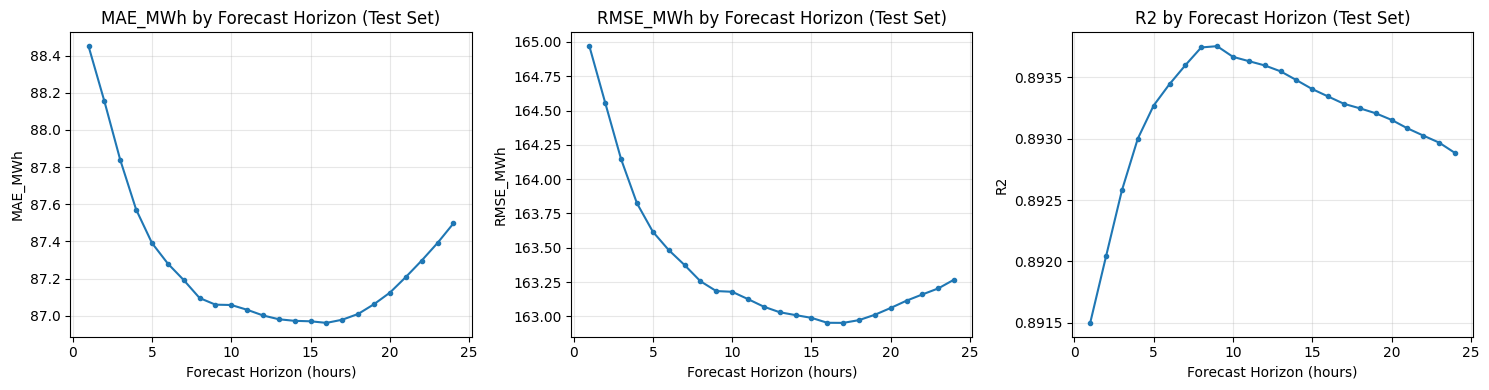

  MAE_MWh   RMSE_MWh       R2  nRMSE_pct  horizon_h
88.450516 164.969025 0.891499  49.130295          1
88.153923 164.555786 0.892042  49.007229          2
87.838135 164.145706 0.892579  48.885101          3
87.571289 163.824097 0.893000  48.789322          4
87.390839 163.617050 0.893270  48.727657          5
87.280205 163.483551 0.893444  48.687901          6
87.191795 163.374146 0.893598  48.655319          7
87.095062 163.256073 0.893743  48.620155          8
87.059219 163.184311 0.893754  48.598785          9
87.057396 163.179092 0.893667  48.597229         10
87.031685 163.125656 0.893632  48.581314         11
87.001152 163.070328 0.893597  48.564835         12
86.980621 163.030014 0.893549  48.552834         13
86.972115 163.009048 0.893477  48.546589         14
86.969711 162.989151 0.893404  48.540661         15
86.961143 162.953140 0.893344  48.529938         16
86.978294 162.952393 0.893284  48.529713         17
87.009377 162.972610 0.893247  48.535736         18
87.061874 16

In [8]:
# ── Per-horizon metrics ──
horizon_metrics = []
for h in range(MAX_PREDICTION_LENGTH):
    pred_h   = np.clip(denormalize(pred_z[:, h]), 0, None)
    actual_h = denormalize(actual_z[:, h])
    m = compute_metrics(actual_h, pred_h)
    m['horizon_h'] = h + 1
    horizon_metrics.append(m)

horizon_df = pd.DataFrame(horizon_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE_MWh', 'RMSE_MWh', 'R2']):
    ax.plot(horizon_df['horizon_h'], horizon_df[metric], marker='o', markersize=3)
    ax.set_xlabel('Forecast Horizon (hours)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Forecast Horizon (Test Set)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(horizon_df.to_string(index=False))

## Step 4 — Baseline comparisons

Compare the TFT against two simple baselines:

- **Persistence (24h):** predict the same hour from 24 hours ago
- **Climatological (hourly):** predict the average generation for each hour-of-day from the training set

In [9]:
# ── Persistence baseline: same hour 24h ago ──
test_gen = denormalize(test_df[TARGET].values)
persistence_pred   = test_gen[:-24]
persistence_actual = test_gen[24:]
persistence_metrics = compute_metrics(persistence_actual, persistence_pred)

# ── Climatological baseline: hourly mean from training set ──
train_gen_mwh = denormalize(train_df[TARGET].values)
train_hours   = pd.to_datetime(train_df['datetime_utc']).dt.hour
hourly_means  = pd.Series(train_gen_mwh, index=train_hours.values).groupby(level=0).mean()

test_hours = pd.to_datetime(test_df['datetime_utc']).dt.hour.values
clim_pred  = hourly_means.loc[test_hours].values
clim_actual = test_gen
clim_metrics = compute_metrics(clim_actual, clim_pred)

# ── Comparison table ──
print(f"\n{'Model':<25s} {'RMSE (MWh)':>12s} {'MAE (MWh)':>12s} {'R²':>8s}")
print("-" * 60)
print(f"{'TFT (ours)':<25s} {test_metrics['RMSE_MWh']:12.2f} {test_metrics['MAE_MWh']:12.2f} {test_metrics['R2']:8.4f}")
print(f"{'Persistence (24h)':<25s} {persistence_metrics['RMSE_MWh']:12.2f} {persistence_metrics['MAE_MWh']:12.2f} {persistence_metrics['R2']:8.4f}")
print(f"{'Climatological (hourly)':<25s} {clim_metrics['RMSE_MWh']:12.2f} {clim_metrics['MAE_MWh']:12.2f} {clim_metrics['R2']:8.4f}")


Model                       RMSE (MWh)    MAE (MWh)       R²
------------------------------------------------------------
TFT (ours)                      163.29        87.32   0.8935
Persistence (24h)               236.37       116.24   0.7755
Climatological (hourly)         279.57       173.41   0.6878


## Step 5 — Visualizations

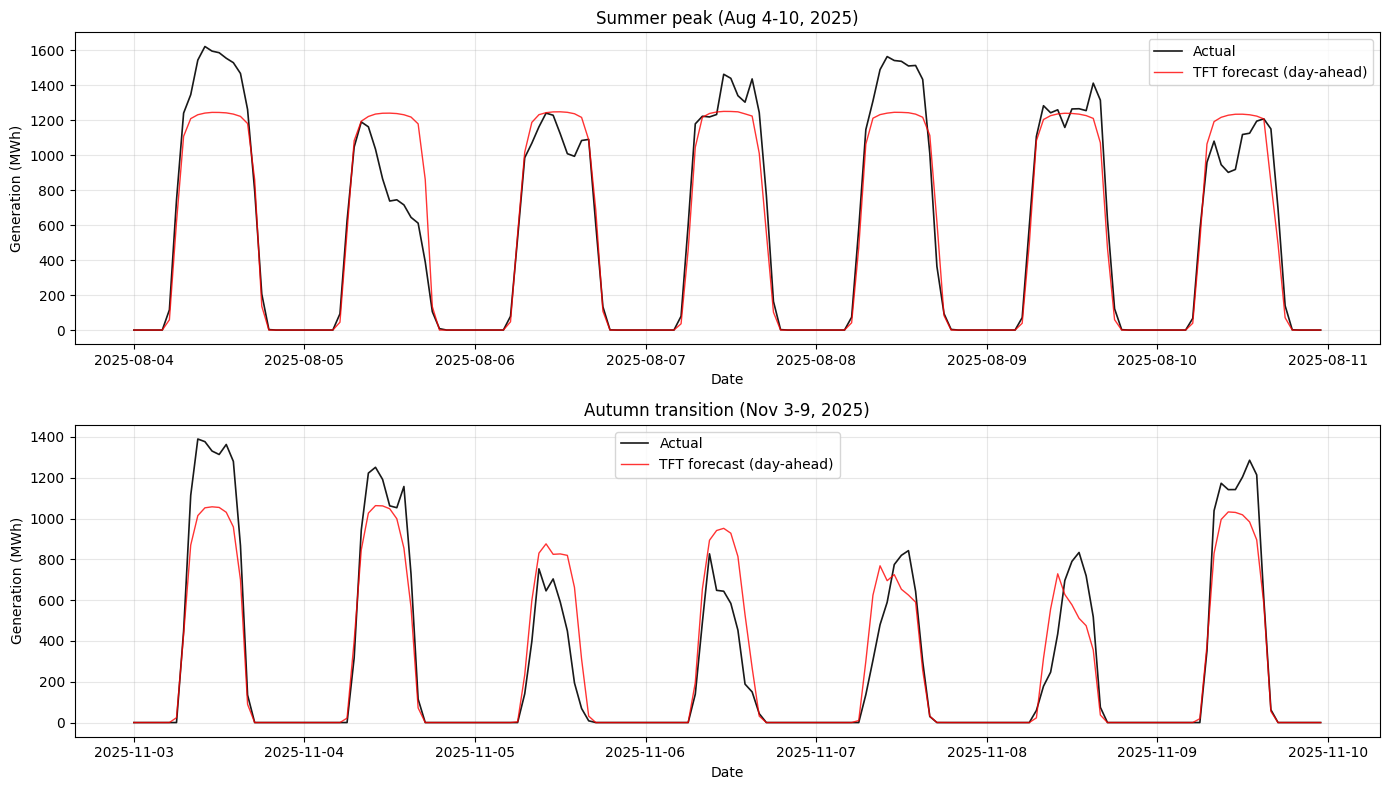

In [10]:
# ── 5a: Time series — selected test weeks ──
# Build day-ahead forecast series by taking the window that starts at 00:00
# each day and using its full 24h prediction. This mirrors real deployment:
# one forecast run per day covering the next 24 hours.
test_datetime = pd.to_datetime(test_df['datetime_utc'])
n_windows = pred_z.shape[0]

dayahead_pred   = {}
dayahead_actual = {}
for i in range(n_windows):
    ts = test_datetime.iloc[i]
    if ts.hour == 0:
        for h in range(MAX_PREDICTION_LENGTH):
            idx = i + h
            if idx < len(test_df):
                t = test_datetime.iloc[idx]
                dayahead_pred[t]   = np.clip(denormalize(pred_z[i, h]), 0, None)
                dayahead_actual[t] = denormalize(test_df[TARGET].iloc[idx])

pred_dayahead_series   = pd.Series(dayahead_pred)
actual_dayahead_series = pd.Series(dayahead_actual)

week_starts = [
    ('Summer peak (Aug 4-10, 2025)', '2025-08-04', '2025-08-10'),
    ('Autumn transition (Nov 3-9, 2025)', '2025-11-03', '2025-11-09'),
]

fig, axes = plt.subplots(len(week_starts), 1, figsize=(14, 4 * len(week_starts)))
if len(week_starts) == 1:
    axes = [axes]

for ax, (title, start, end) in zip(axes, week_starts):
    end_ts = end + ' 23:00:00'
    actual_week = actual_dayahead_series[start:end_ts]
    pred_week   = pred_dayahead_series[start:end_ts]
    ax.plot(actual_week.index, actual_week.values, 'k-', linewidth=1.2, label='Actual', alpha=0.9)
    ax.plot(pred_week.index,   pred_week.values,   'r-', linewidth=1.0, label='TFT forecast (day-ahead)', alpha=0.8)
    ax.set_xlabel('Date')
    ax.set_ylabel('Generation (MWh)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

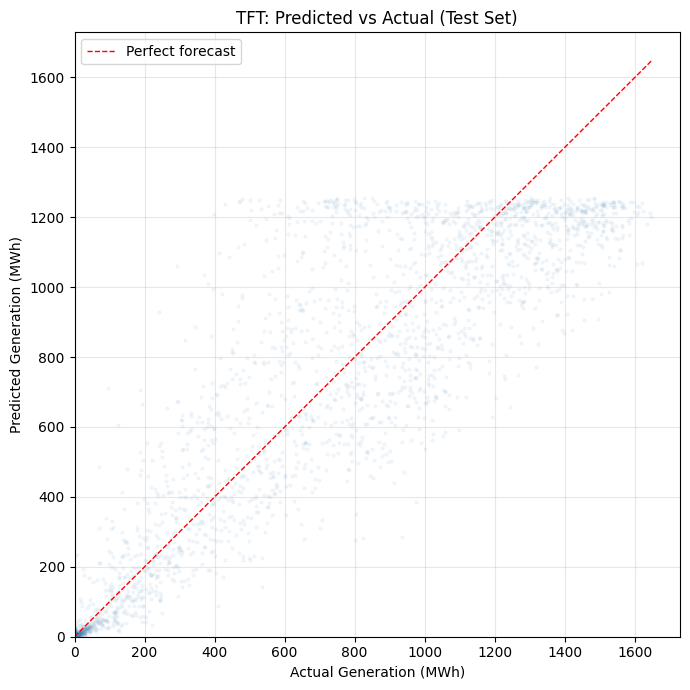

In [11]:
# ── 5b: Scatter plot — predicted vs actual ──
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual_mwh, pred_mwh, alpha=0.05, s=5, c='steelblue')
max_val = max(actual_mwh.max(), pred_mwh.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect forecast')
ax.set_xlabel('Actual Generation (MWh)')
ax.set_ylabel('Predicted Generation (MWh)')
ax.set_title('TFT: Predicted vs Actual (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max_val * 1.05)
ax.set_ylim(0, max_val * 1.05)
plt.tight_layout()
plt.show()

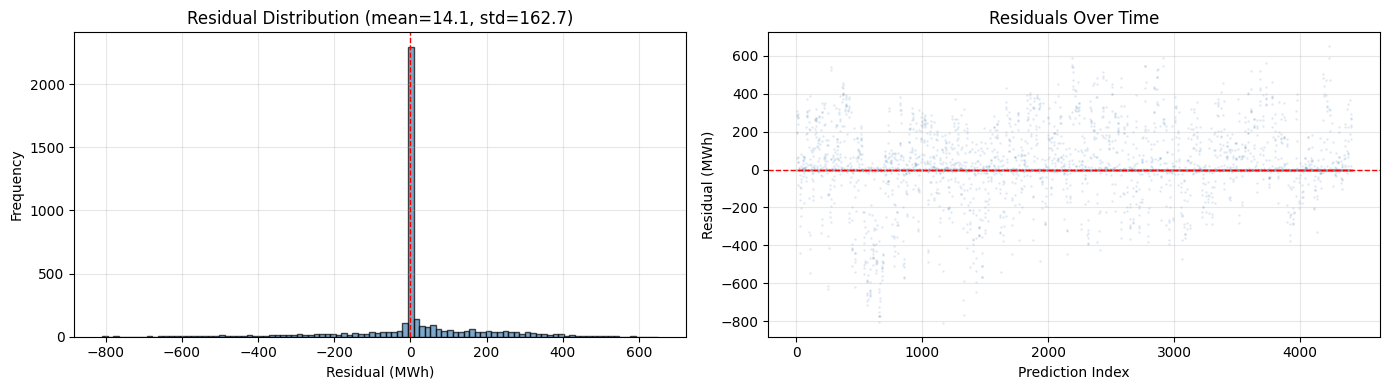

In [12]:
# ── 5c: Residual analysis ──
residuals = actual_mwh - pred_mwh

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Residual (MWh)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Residual Distribution (mean={residuals.mean():.1f}, std={residuals.std():.1f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(np.arange(len(residuals)), residuals, s=1, alpha=0.1, c='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Prediction Index')
axes[1].set_ylabel('Residual (MWh)')
axes[1].set_title('Residuals Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

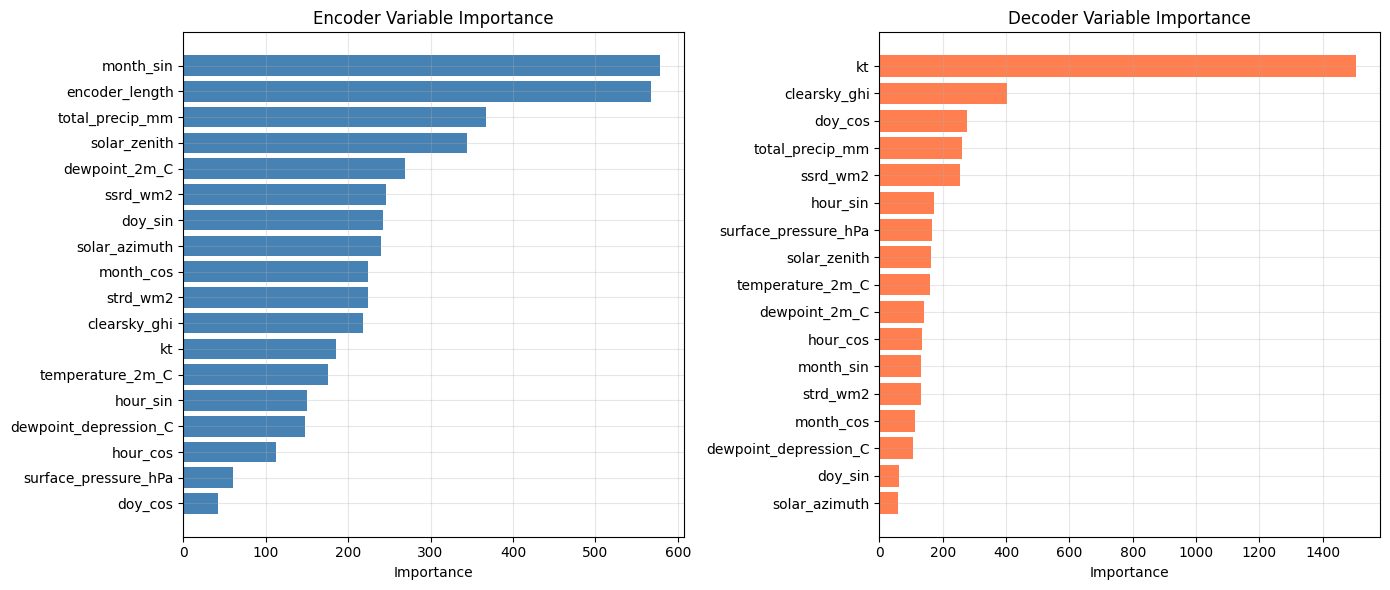

In [13]:
# ── 5d: TFT interpretability — variable importance ──
interpretation = best_model.interpret_output(test_raw.output, reduction='sum')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Encoder variable importance — all real-valued encoder inputs
enc_vars = training_dataset.reals
enc_imp  = interpretation['encoder_variables'].cpu().numpy()
enc_sorted = sorted(zip(enc_vars, enc_imp), key=lambda x: x[1], reverse=True)
enc_names, enc_vals = zip(*enc_sorted)
axes[0].barh(range(len(enc_names)), enc_vals, color='steelblue')
axes[0].set_yticks(range(len(enc_names)))
axes[0].set_yticklabels(enc_names)
axes[0].set_xlabel('Importance')
axes[0].set_title('Encoder Variable Importance')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

# Decoder variable importance — only known-future variables (visible at prediction time)
dec_vars = list(training_dataset.time_varying_known_reals)
dec_imp  = interpretation['decoder_variables'].cpu().numpy()
dec_sorted = sorted(zip(dec_vars, dec_imp), key=lambda x: x[1], reverse=True)
dec_names, dec_vals = zip(*dec_sorted)
axes[1].barh(range(len(dec_names)), dec_vals, color='coral')
axes[1].set_yticks(range(len(dec_names)))
axes[1].set_yticklabels(dec_names)
axes[1].set_xlabel('Importance')
axes[1].set_title('Decoder Variable Importance')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

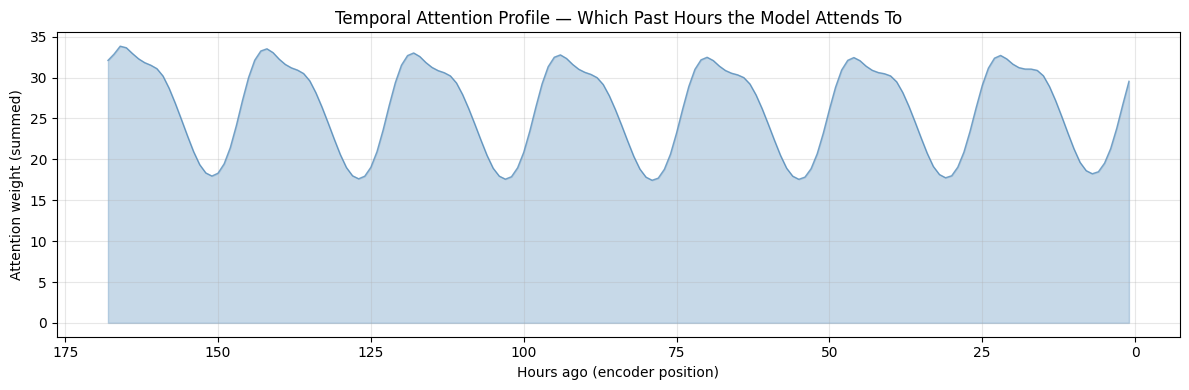

Attention shape: (168,)
Peak attention at 166h ago


In [14]:
# ── 5e: Temporal attention pattern ──
attention = interpretation['attention'].cpu().numpy()  # (encoder_length,) after reduction='sum'

fig, ax = plt.subplots(figsize=(12, 4))
hours_ago = np.arange(MAX_ENCODER_LENGTH, 0, -1)
ax.plot(hours_ago, attention, linewidth=1, color='steelblue', alpha=0.7)
ax.fill_between(hours_ago, attention, alpha=0.3, color='steelblue')
ax.invert_xaxis()
ax.set_xlabel('Hours ago (encoder position)')
ax.set_ylabel('Attention weight (summed)')
ax.set_title('Temporal Attention Profile — Which Past Hours the Model Attends To')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Attention shape: {attention.shape}")
print(f"Peak attention at {hours_ago[attention.argmax()]}h ago")


## Step 6 — Summary

In [15]:
print("=" * 70)
print("FINAL TEST RESULTS — Zaragoza TFT Solar Forecast")
print("=" * 70)

print(f"\nModel: Temporal Fusion Transformer")
print(f"Test period: 2025-07-01 to 2025-12-31")
print(f"Encoder length: {MAX_ENCODER_LENGTH}h ({MAX_ENCODER_LENGTH//24} days)")
print(f"Prediction length: {MAX_PREDICTION_LENGTH}h (day-ahead)")

print(f"\nHyperparameters (selected via Optuna, {hp_results['n_trials']} trials):")
for k, v in hp_results['best_params'].items():
    print(f"  {k}: {v}")

print(f"\n{'Metric':<15s} {'Validation':>12s} {'Test':>12s}")
print("-" * 42)
for metric in ['RMSE_MWh', 'MAE_MWh', 'R2']:
    val_v  = hp_results['val_metrics_mwh'][metric]
    test_v = test_metrics[metric]
    fmt = '.2f' if 'MWh' in metric else '.4f'
    print(f"{metric:<15s} {val_v:12{fmt}} {test_v:12{fmt}}")
print(f"{'MASE':<15s} {'—':>12s} {mase:12.4f}")

print(f"\nBaseline comparison (test set):")
print(f"  TFT R²:          {test_metrics['R2']:.4f}")
print(f"  Persistence R²:  {persistence_metrics['R2']:.4f}")
print(f"  Climatology R²:  {clim_metrics['R2']:.4f}")

print(f"\nMASE = {mase:.4f} → {'TFT outperforms persistence' if mase < 1 else 'Persistence is competitive'}")
print("=" * 70)

FINAL TEST RESULTS — Zaragoza TFT Solar Forecast

Model: Temporal Fusion Transformer
Test period: 2025-07-01 to 2025-12-31
Encoder length: 168h (7 days)
Prediction length: 24h (day-ahead)

Hyperparameters (selected via Optuna, 15 trials):
  hidden_size: 16
  lstm_layers: 1
  attention_head_size: 4
  dropout: 0.21388127302606708
  hidden_continuous_size: 8
  learning_rate: 0.000335154783106822

Metric            Validation         Test
------------------------------------------
RMSE_MWh              168.16       163.29
MAE_MWh                91.43        87.32
R2                    0.8663       0.8935
MASE                       —       0.7512

Baseline comparison (test set):
  TFT R²:          0.8935
  Persistence R²:  0.7755
  Climatology R²:  0.6878

MASE = 0.7512 → TFT outperforms persistence


In [16]:
# Save test metrics so 5c three-way table uses test (not val) metrics
pf_json_path = os.path.join(MODEL_DIR, 'hp_study_results_pf.json')
with open(pf_json_path) as f:
    pf_data = json.load(f)

pf_data['test_metrics_mwh'] = {
    'RMSE_MWh': test_metrics['RMSE_MWh'],
    'MAE_MWh':  test_metrics['MAE_MWh'],
    'R2':       test_metrics['R2'],
}

with open(pf_json_path, 'w') as f:
    json.dump(pf_data, f, indent=2)

print(f"Saved test metrics to {pf_json_path}")
print(f"  R²:   {test_metrics['R2']:.4f}")
print(f"  RMSE: {test_metrics['RMSE_MWh']:.2f} MWh")
print(f"  MAE:  {test_metrics['MAE_MWh']:.2f} MWh")

# Save test predictions CSV for bootstrap CI
test_pred_df = pd.DataFrame({
    'actual_mwh': actual_mwh,
    'predicted_mwh': pred_mwh,
})
test_pred_path = os.path.join(MODEL_DIR, 'test_predictions.csv')
test_pred_df.to_csv(test_pred_path, index=False)
print(f'Saved test predictions: {test_pred_path} ({len(test_pred_df)} rows)')

Saved test metrics to c:\Users\nicol\Documents\ML-solar-forecast\zaragoza\models\perfect_forecast\hp_study_results_pf.json
  R²:   0.8935
  RMSE: 163.29 MWh
  MAE:  87.32 MWh
Saved test predictions: c:\Users\nicol\Documents\ML-solar-forecast\zaragoza\models\perfect_forecast\test_predictions.csv (4416 rows)


In [17]:
# Free GPU memory before moving to next notebook
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print("GPU memory released.")

GPU memory released.
